# Evaluation

In [1]:
import torch
import kornia.feature as KF
import os
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset, DataLoader

c:\Users\EasyMoneySniper\anaconda3\envs\nlp-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from models import StudentHybrid, StudentCNN, StudentHybridConfig, StudentCNNConfig

# Training Losses

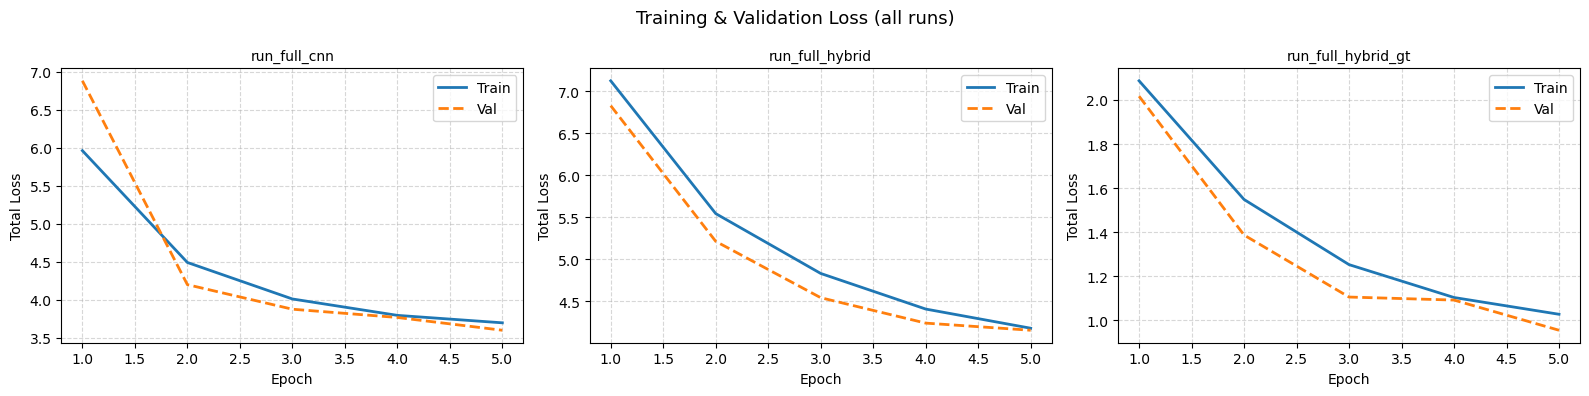


run_full_cnn
 epoch  train_total  train_coarse_kd  train_feat_kd  train_gt_sup  val_total  val_coarse_kd  val_feat_kd  val_gt_sup
     1     5.960077         1.975075       4.594421      1.687792   6.877995       2.314285     4.429035    2.349193
     2     4.490173         1.309743       3.911321      1.224769   4.198683       1.174326     3.598318    1.225197
     3     4.010508         1.133099       3.427270      1.163774   3.875865       1.069526     3.267820    1.172429
     4     3.795026         1.064107       3.218004      1.121917   3.767253       1.046413     3.221143    1.110268
     5     3.696993         1.040856       3.165192      1.073540   3.599316       0.995178     3.195240    1.006518

run_full_hybrid
 epoch  train_total  train_coarse_kd  train_feat_kd  train_gt_sup  val_total  val_coarse_kd  val_feat_kd  val_gt_sup
     1     7.125313         2.646111       4.514734      2.221835   6.828960       2.444263     4.239983    2.264706
     2     5.543898         1.839

In [3]:
# Load the epoch_losses.csv file for all three runs
runs = ["run_full_cnn", "run_full_hybrid", "run_full_hybrid_gt"]
loss_dfs = {}
for run in runs:
    csv_path = f"../checkpoints/{run}/epoch_losses.csv"
    if os.path.exists(csv_path):
        loss_dfs[run] = pd.read_csv(csv_path)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, run in zip(axes, runs):
    df = loss_dfs.get(run)
    if df is None:
        ax.set_title(f"{run}\n(no data)")
        continue
    ax.plot(df["epoch"], df["train_total"], label="Train", linewidth=2)
    ax.plot(df["epoch"], df["val_total"],   label="Val",   linewidth=2, linestyle="--")
    ax.set_title(run, fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Total Loss")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Training & Validation Loss (all runs)", fontsize=13)
plt.tight_layout()
plt.show()

for run, df in loss_dfs.items():
    print(f"\n{'='*60}\n{run}")
    print(df.to_string(index=False))

# Load all models

In [4]:
# load the models
cnn_path = "../checkpoints/run_full_cnn/epoch_05.pth"
hybrid_path = "../checkpoints/run_full_hybrid/epoch_05.pth"
hybrid_gt_path = "../checkpoints/run_full_hybrid_gt/epoch_05.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
CNN_model = StudentCNN(StudentCNNConfig()).to(device)
Hybrid_model = StudentHybrid(StudentHybridConfig()).to(device)
Hybrid_gt_model = StudentHybrid(StudentHybridConfig()).to(device)

In [6]:
def load_checkpoint(model, path, device):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    val_total = ckpt.get("val_loss", {}).get("total", float("nan"))
    print(f"Loaded {path}  |  epoch={ckpt.get('epoch')}  val_loss={val_total:.4f}")

load_checkpoint(CNN_model,       cnn_path,       device)
load_checkpoint(Hybrid_model,    hybrid_path,    device)
load_checkpoint(Hybrid_gt_model, hybrid_gt_path, device)

Loaded ../checkpoints/run_full_cnn/epoch_05.pth  |  epoch=5  val_loss=3.5993
Loaded ../checkpoints/run_full_hybrid/epoch_05.pth  |  epoch=5  val_loss=4.1546
Loaded ../checkpoints/run_full_hybrid_gt/epoch_05.pth  |  epoch=5  val_loss=0.9544


C:\Users\EasyMoneySniper\AppData\Local\Temp\ipykernel_29652\2393333964.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=device)


## Hpatches Evaluation
Our plan is to evaluate Hpatches with the three following strategies:
1. Matching Precision
2. Inlier ratio
3. AUC@{3,5,10}px

In [7]:
HPATCHES_PATH = "../hpatches-sequences-release"

# ── Data loading ───────────────────────────────────────────────────────────────
def load_hpatches_pairs(hpatches_path):
    pairs = []
    for seq_path in sorted(Path(hpatches_path).iterdir()):
        if not seq_path.is_dir():
            continue
        seq_name = seq_path.name
        img_ref = cv2.imread(str(seq_path / "1.ppm"))
        for i in range(2, 7):
            img_test = cv2.imread(str(seq_path / f"{i}.ppm"))
            H_gt = np.loadtxt(str(seq_path / f"H_1_{i}"))
            pairs.append({
                "seq": seq_name, "idx": i,
                "img0": img_ref, "img1": img_test, "H_gt": H_gt,
                "type": "illumination" if seq_name.startswith("i_") else "viewpoint",
            })
    return pairs

pairs = load_hpatches_pairs(HPATCHES_PATH)
print(f"Total pairs: {len(pairs)}")

# ── Image preprocessing ────────────────────────────────────────────────────────
def preprocess_image(img, short_edge=480):
    h, w = img.shape[:2]
    scale = short_edge / min(h, w)
    new_w = int(w * scale) // 8 * 8
    new_h = int(h * scale) // 8 * 8
    return cv2.resize(img, (new_w, new_h)), new_w / w, new_h / h

def to_gray_tensor(img, dev):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return torch.from_numpy(gray).float().unsqueeze(0).unsqueeze(0).to(dev) / 255.0

# ── Geometry helpers ───────────────────────────────────────────────────────────
def scale_homography(H_gt, sx0, sy0, sx1, sy1):
    """Scale H_gt (original resolution) into the resized coordinate system."""
    S0     = np.array([[sx0,   0, 0], [0, sy0,   0], [0, 0, 1]], dtype=np.float64)
    S1_inv = np.array([[1/sx1, 0, 0], [0, 1/sy1, 0], [0, 0, 1]], dtype=np.float64)
    return S0 @ H_gt @ S1_inv

def estimate_homography(mkpts0, mkpts1, ransac_thr=3.0):
    """Return (H, inlier_ratio). H is None if fewer than 4 matches."""
    if len(mkpts0) < 4:
        return None, 0.0
    H, mask = cv2.findHomography(mkpts0, mkpts1, cv2.RANSAC, ransac_thr,
                                 confidence=0.99999, maxIters=10000)
    inl = float(mask.sum() / len(mask)) if mask is not None else 0.0
    return H, inl

def corner_transfer_error(H_pred, H_gt, img_shape):
    """Mean L2 error (px) between corners projected by H_pred vs H_gt."""
    if H_pred is None:
        return None
    h, w = img_shape[:2]
    corners = np.array([[0,0],[w-1,0],[w-1,h-1],[0,h-1]],
                       dtype=np.float32).reshape(1, -1, 2)
    pred_pts = cv2.perspectiveTransform(corners, H_pred).reshape(-1, 2)
    gt_pts   = cv2.perspectiveTransform(corners, H_gt).reshape(-1, 2)
    return float(np.mean(np.linalg.norm(pred_pts - gt_pts, axis=1)))

# ── Per-match metric helpers ───────────────────────────────────────────────────
def matching_precision(mkpts0, mkpts1, H_gt, threshold=3.0):
    """Fraction of predicted matches that are correct (< threshold px under H_gt)."""
    if len(mkpts0) == 0:
        return 0.0
    pts0_h = np.concatenate([mkpts0, np.ones((len(mkpts0), 1))], axis=1)
    proj   = (H_gt @ pts0_h.T).T
    proj   = proj[:, :2] / proj[:, 2:3]
    return float(np.mean(np.linalg.norm(proj - mkpts1, axis=1) < threshold))

def auc_at(errors, max_thr):
    """AUC of correctness curve over [0, max_thr]. errors: list of float|None."""
    xs = np.linspace(0, max_thr, 1000)
    ys = np.array([np.mean([(e is not None) and (e <= t) for e in errors]) for t in xs])
    return float(np.trapezoid(ys, xs) / max_thr)

# ── Model inference wrappers ───────────────────────────────────────────────────
loftr_model = KF.LoFTR(pretrained='outdoor').eval().to(device)

def run_loftr(img0, img1):
    img0_r, sx0, sy0 = preprocess_image(img0)
    img1_r, sx1, sy1 = preprocess_image(img1)
    with torch.no_grad():
        corr = loftr_model({"image0": to_gray_tensor(img0_r, device),
                            "image1": to_gray_tensor(img1_r, device)})
    return (corr["keypoints0"].cpu().numpy(),
            corr["keypoints1"].cpu().numpy(),
            img0_r.shape, (sx0, sy0), (sx1, sy1))

def run_student(model, img0, img1):
    img0_r, sx0, sy0 = preprocess_image(img0)
    img1_r, sx1, sy1 = preprocess_image(img1)
    with torch.no_grad():
        out = model({"image0": to_gray_tensor(img0_r, device),
                     "image1": to_gray_tensor(img1_r, device)})
    return (out["keypoints0"].cpu().numpy(),
            out["keypoints1"].cpu().numpy(),
            img0_r.shape, (sx0, sy0), (sx1, sy1))

# ── Full HPatches evaluation loop ──────────────────────────────────────────────
def evaluate_on_hpatches(run_fn, pairs, desc=""):
    results = []
    for pair in tqdm(pairs, desc=desc):
        img0, img1, H_gt = pair["img0"], pair["img1"], pair["H_gt"]
        mkpts0, mkpts1, shape0_r, scale0, scale1 = run_fn(img0, img1)
        H_gt_s        = scale_homography(H_gt, scale0[0], scale0[1], scale1[0], scale1[1])
        prec          = matching_precision(mkpts0, mkpts1, H_gt_s)
        H_pred, inl   = estimate_homography(mkpts0, mkpts1)
        err           = corner_transfer_error(H_pred, H_gt_s, shape0_r)
        results.append({
            "seq": pair["seq"], "idx": pair["idx"], "type": pair["type"],
            "n_matches": len(mkpts0), "precision": prec,
            "inlier_ratio": inl, "error": err,
        })
    return results

# Set student models to eval mode
CNN_model.eval()
Hybrid_model.eval()
Hybrid_gt_model.eval()

results_cnn       = evaluate_on_hpatches(
    lambda i0, i1: run_student(CNN_model, i0, i1),       pairs, "StudentCNN")
results_hybrid    = evaluate_on_hpatches(
    lambda i0, i1: run_student(Hybrid_model, i0, i1),    pairs, "StudentHybrid")
results_hybrid_gt = evaluate_on_hpatches(
    lambda i0, i1: run_student(Hybrid_gt_model, i0, i1), pairs, "StudentHybrid-GT")
results_loftr     = evaluate_on_hpatches(
    run_loftr,                                            pairs, "LoFTR")

Total pairs: 580


LoFTR: 100%|██████████| 580/580 [00:57<00:00, 10.07it/s]


In [8]:
THRESHOLDS = [3, 5, 10]

model_results = {
    "StudentCNN":       results_cnn,
    "StudentHybrid":    results_hybrid,
    "StudentHybrid-GT": results_hybrid_gt,
    "LoFTR":            results_loftr,
}

rows = []
for model_name, results in model_results.items():
    errors = [r["error"] for r in results]
    prec   = np.mean([r["precision"]    for r in results])
    inl    = np.mean([r["inlier_ratio"] for r in results])
    row = {
        "Model":               model_name,
        "Matching Precision":  round(prec * 100, 2),
        "Inlier Ratio (%)":    round(inl  * 100, 2),
    }
    for t in THRESHOLDS:
        row[f"AUC@{t}px (%)"] = round(auc_at(errors, t) * 100, 2)
    rows.append(row)

df_results = pd.DataFrame(rows).set_index("Model")
print(df_results.to_string())
df_results

                  Matching Precision  Inlier Ratio (%)  AUC@3px (%)  AUC@5px (%)  AUC@10px (%)
Model                                                                                         
StudentCNN                      3.82              2.00         0.00         0.04          0.33
StudentHybrid                   0.00              0.00         0.00         0.00          0.00
StudentHybrid-GT               41.52             32.58        16.22        19.46         23.10
LoFTR                          82.50             91.55        61.26        69.47         77.58


,Matching Precision,Inlier Ratio (%),AUC@3px (%),AUC@5px (%),AUC@10px (%)
Model,,,,,
StudentCNN,3.82,2.00,0.00,0.04,0.33
StudentHybrid,0.00,0.00,0.00,0.00,0.00
StudentHybrid-GT,41.52,32.58,16.22,19.46,23.10
LoFTR,82.50,91.55,61.26,69.47,77.58
